In [1]:
# load relevant libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# load the weekly interval df
weekly_sentiments = pd.read_csv("../01_data/clean_labelled_data/weekly_sentiment_scores.csv")

After having loaded all packages and the labelled data, I reduce the dataset to consist of solely posts sent from politicians from the SPD, Greens and Die Linke. Then, I create a categorical variable that indicates if the post was sent before the election campaign, during the campaign or after the election. I remove the period between the election date and the start of the new government. The deleted period consists of three months which is a rather conservative approach since the party composition of the government was clear before May. Therefore, this is the robustness check of my findings in the main analysis which deleted only the period from the election until the constitution of the new parliament in March.

In [2]:
# reduce the df to the relevant parties and make a copy
weekly_sentiments_subset = weekly_sentiments[
    weekly_sentiments["faction"].isin(["SPD", "Grünen", "Die LINKE"])
].copy()

# convert week column to datetime
weekly_sentiments_subset["week_start"] = pd.to_datetime(weekly_sentiments_subset["week_start"])

# remove period of the caretaker government
weekly_sentiments_subset = weekly_sentiments_subset[
    (weekly_sentiments_subset["week_start"] <= "2025-02-23") | 
    (weekly_sentiments_subset["week_start"] >= "2025-05-25")
]

# add column marking the electoral period
weekly_sentiments_subset["period"] = pd.cut(
    weekly_sentiments_subset["week_start"],
    bins=[
        pd.Timestamp.min,
        pd.to_datetime("2024-12-27"),
        pd.to_datetime("2025-02-23"),
        pd.Timestamp.max
    ],
    labels=["pre-campaign", "campaign", "post-election"],
    right=True
)

I run the multilevel regression and print the summary report below.

In [3]:
# run the analysis
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    model = smf.mixedlm(
        "mean_sentiment_score ~ period * faction + week_index + gender + mandate + age",
        data=weekly_sentiments_subset,
        groups=weekly_sentiments_subset["full_name"],
        re_formula="~ week_index"
    )
    result = model.fit(method="lbfgs")

# print the regression summary
print(result.summary())

                       Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       mean_sentiment_score
No. Observations:       2032          Method:                   REML                
No. Groups:             138           Scale:                    5.1204              
Min. group size:        1             Log-Likelihood:           -4630.8920          
Max. group size:        49            Converged:                No                  
Mean group size:        14.7                                                        
------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------
Intercept                                 -1.722    0.710 -2.425 0.015 -3.114 -0.330
period[T.campaign]                         0.292    0.423  0.690 0.490 -0.537  1.121
peri

This is the same code for the bootstrap estimations as in the main analysis. I only work with the converged models and print which proportion of models failed to converge below.

In [4]:
# encode the object-type variables as categories
weekly_sentiments_subset["faction"] = weekly_sentiments_subset["faction"].astype("category")
weekly_sentiments_subset["period"] = weekly_sentiments_subset["period"].astype("category")
weekly_sentiments_subset["gender"] = weekly_sentiments_subset["gender"].astype("category")
weekly_sentiments_subset["mandate"] = weekly_sentiments_subset["mandate"].astype("category")

# extract all categories from factions and periods
factions = weekly_sentiments_subset["faction"].cat.categories
periods = weekly_sentiments_subset["period"].cat.categories

# create a grid with all combinations of faction and period
grid = pd.DataFrame(
    [(f, p) for f in factions for p in periods],
    columns=["faction", "period"]
)

# set covariates to typical/reference values from the original data
grid["week_index"] = weekly_sentiments_subset["week_index"].mean()
grid["age"] = weekly_sentiments_subset["age"].mean()
grid["gender"] = weekly_sentiments_subset["gender"].mode()[0]
grid["mandate"] = weekly_sentiments_subset["mandate"].mode()[0]

# ensure that the categories match in the grid with the actual categories
for col in ["faction","period","gender","mandate"]:
    grid[col] = pd.Categorical(grid[col], categories=weekly_sentiments_subset[col].cat.categories)

# create empty lists to store bootstrap predictions and coefficients
boot_preds = []
boot_coefs = []

# get all unique MP names (for resampling)
groups = weekly_sentiments_subset["full_name"].unique()

# create variables for the number of bootstrap iterations and to store number of non-converged models
n_boot = 1000
num_non_convergence = 0

# loop over all bootstrap iterations
for i in range(n_boot):

    # resample clusters (MPs) with replacement
    sampled_groups = np.random.choice(groups, size=len(groups), replace=True)
    boot_df = pd.concat([weekly_sentiments_subset[weekly_sentiments_subset["full_name"]==g] for g in sampled_groups])
    
    # fit model on the bootstrap df
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        warnings.simplefilter("ignore", UserWarning)
        boot_model = smf.mixedlm(
            "mean_sentiment_score ~ period * faction + week_index + gender + mandate + age",
            data=boot_df,
            groups=boot_df["full_name"],
            re_formula="~ week_index"
        ).fit(method="lbfgs")
    
    # check if the model converged, only store predictions if it did
    if not boot_model.converged:
        num_non_convergence += 1
    else:
        # predict for all rows in the grid and append to list
        pred = boot_model.predict(grid)
        boot_preds.append(pred.values)
        # extract all coefficients and append to list
        coef_list = [boot_model.params.iloc[i] for i in range(len(boot_model.params))]
        boot_coefs.append(coef_list)

# print how many models did not converge
prop_non_convergence = (num_non_convergence/n_boot)*100
print(f"{prop_non_convergence:.2f}% of all bootstrap models failed to converge.")
        
# convert to numpy array for percentile calculation
boot_preds = np.array(boot_preds)

# calculate mean of bootstrap predictions as well as confidence intervals
grid["mean"] = boot_preds.mean(axis=0)
grid["ci_lower"] = np.percentile(boot_preds, 2.5, axis=0)
grid["ci_upper"] = np.percentile(boot_preds, 97.5, axis=0)

12.70% of all bootstrap models failed to converge.


This is the core part of the robustness check in which I plot the predicted mean sentiment scores for all interaction effects. All the main findings from the main analysis do hold here. A more detailed interpretation can be found in the report.

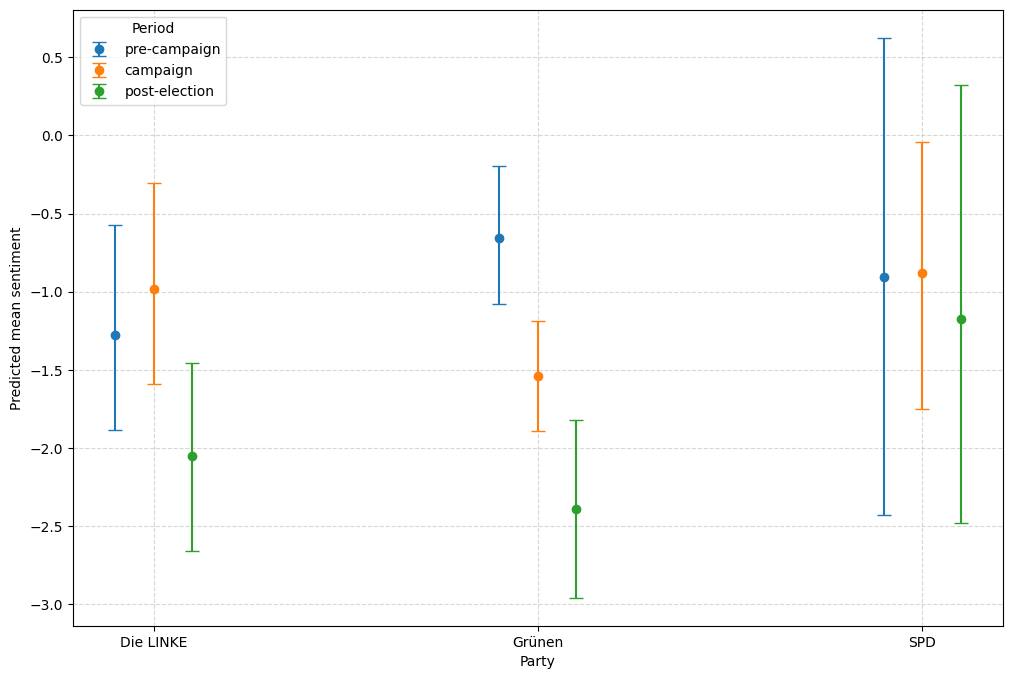

In [5]:
# create a plot with predicted sentiment for the interaction effects
plt.figure(figsize=(12,8))

# set parties as x-axis and set width between estimates
x = np.arange(len(factions))
width = 0.1

# get all distinct periods
periods_list = grid["period"].cat.categories

cmap = plt.colormaps["tab10"]
colors = [cmap(i) for i in range(len(periods_list))]

# loop over periods and subset the df for the current period
for i, period in enumerate(periods_list):
    subset = grid[grid["period"] == period]
    # plot the point estimate with errorbar for each party
    plt.errorbar(
        x + (i - (len(periods_list)-1)/2)*width,
        subset["mean"],
        yerr=[subset["mean"] - subset["ci_lower"], subset["ci_upper"] - subset["mean"]],
        fmt='o',
        capsize=5,
        color=colors[i],
        label=period
    )

# set plot labels
plt.xticks(x, factions)
plt.ylabel("Predicted mean sentiment")
plt.xlabel("Party")
plt.legend(title="Period")
plt.grid(True, linestyle="--", alpha=0.5)

# export the plot and show
plt.savefig("../02_figures_tables/interaction_effects_robustness.png", dpi=300)
plt.show()